In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [2]:
results_directory = Path("../csv")

s4_data = np.genfromtxt(
    results_directory
    / "s4_fourier_convergence.csv",
    delimiter=",",
    names = True
)

fmmax_data = np.genfromtxt(
    results_directory
    / "fmmax_fourier_convergence.csv",
    delimiter=",",
    names=True
)

print(s4_data)
print(fmmax_data)

[(  5.,  1., 0.02134937) ( 10.,  9., 0.02065755) ( 15.,  9., 0.02065755)
 ( 20.,  9., 0.02065755) ( 25., 25., 0.02038264) ( 30., 25., 0.02038264)
 ( 35., 25., 0.02038264) ( 40., 25., 0.02038264) ( 45., 25., 0.02038264)
 ( 50., 49., 0.0203694 ) ( 55., 49., 0.0203694 ) ( 60., 49., 0.0203694 )
 ( 65., 49., 0.0203694 ) ( 70., 49., 0.0203694 ) ( 75., 49., 0.0203694 )
 ( 80., 49., 0.0203694 ) ( 85., 81., 0.02024503) ( 90., 81., 0.02024503)
 ( 95., 81., 0.02024503) (100., 81., 0.02024503)]
[(  5.,  9., 0.02107202) ( 10.,  9., 0.02107202) ( 15.,  9., 0.02107202)
 ( 20., 25., 0.02081346) ( 25., 25., 0.02081346) ( 30., 25., 0.02081346)
 ( 35., 25., 0.02081346) ( 40., 49., 0.02078664) ( 45., 49., 0.02078664)
 ( 50., 49., 0.02078664) ( 55., 49., 0.02078664) ( 60., 49., 0.02078664)
 ( 65., 81., 0.02064727) ( 70., 81., 0.02064727) ( 75., 81., 0.02064727)
 ( 80., 81., 0.02064727) ( 85., 81., 0.02064727) ( 90., 81., 0.02064727)
 ( 95., 81., 0.02064727) (100., 81., 0.02064727)]


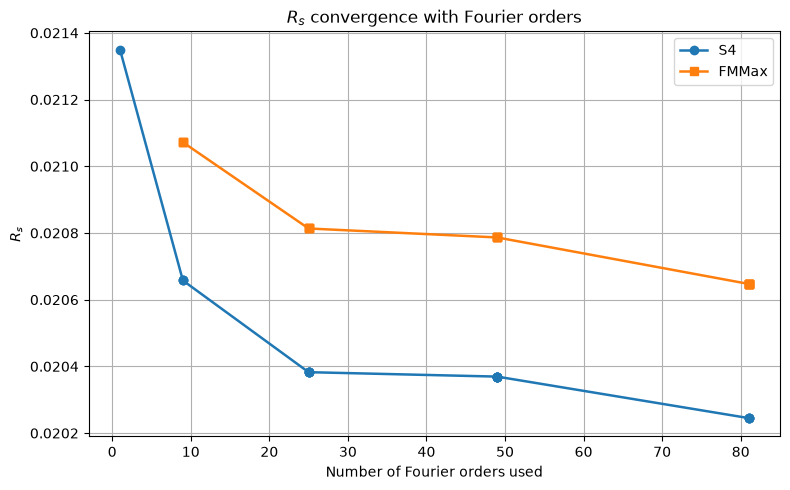

Saved output to ../plots


In [3]:
plt.figure(
    figsize=(8,5)
)

plt.plot(s4_data["actual_orders"],
         s4_data["Rs"],
         marker = "o",
         linewidth=1.8,
         label="S4")

plt.plot(fmmax_data["actual_orders"],
         fmmax_data["Rs"],
         marker="s",
         linewidth=1.8,
         label="FMMax")

plt.xlabel(
    "Number of Fourier orders used"
)

plt.ylabel(
    r"$R_s$"
)

plt.title(
    r"$R_s$ convergence with Fourier orders"
)

plt.grid(visible=True)

plt.legend()

plt.tight_layout()

output_path = Path("../plots")
plt.savefig(output_path,
            dpi=200,
            )

plt.show()

print(f"Saved output to {output_path}")

<function matplotlib.pyplot.show(close=None, block=None)>

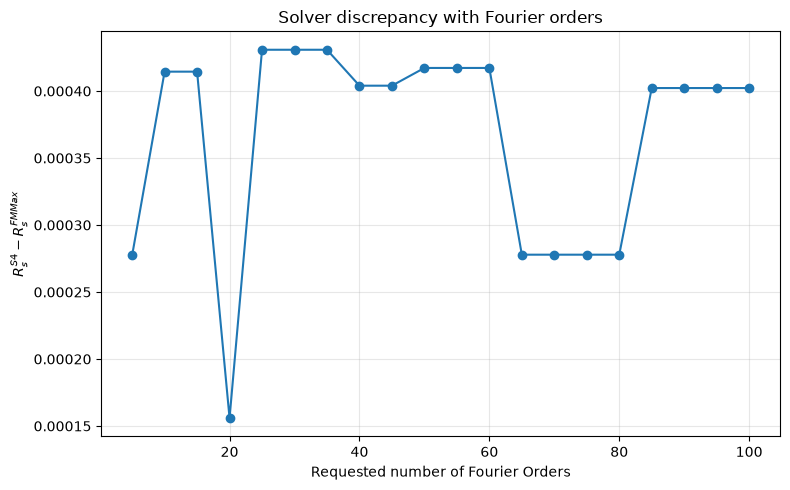

In [4]:
# Check discrepancy

absolute_difference = np.abs(
    s4_data["Rs"] - fmmax_data["Rs"]
)

plt.figure(figsize=(8,5))

plt.plot(
    s4_data["requested_orders"],
    absolute_difference,
    marker="o"
)

plt.xlabel("Requested number of Fourier Orders")
plt.ylabel(r"$R_s^{S4} - R_s^{FMMax}$")
plt.title("Solver discrepancy with Fourier orders")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show